## Python Foundation

***

✔ Objects & Memory  
✔ Mutability  
✔ Identity  
✔ Reference Counting  
✔ Garbage Collection  
✔ Basic Built-in Types (covered when needed)  

***

Q. What Really Happens When You Run a Python Program?  
print("Hello, World!")  
`python hello.py ??  `


* Operating System Launches ->> Python Interpretor --> python.exe starts --> python.exe opens hello.py --> Reads the Code

* Python REPL ??
-- When you open terminal and type `python`
-- You get `>>>`

* `REPL`: Read, Evaluate, Print, Loop  

To read the code, evaluate it, print the output and go for next input


<Q> Q. Is Python code executed directly by CPU ? </Q>

* * No, python source code is just a plain text, The operating system starts the Python Interpreter, which reads the source code and execute it. 

What is `CPython`?
- A programming language, designed to give python code `C-code` like execution speed. Allows you to write pyhton code while leveraging functionality of `C or C++`

# Variables, Objects & Memory

1. what is a variable?  
~~It Stores value.~~

Variable:- `Hold reference to an object .`
It is a name bound to an object

Everything in python is an `object` - variables, function, class, modules, everthings



In [4]:
x = 10
y = x
print(id(x))
print(id(y))

140731165919960
140731165919960


`x -> 10 <- y `    
We assigned the reference `x` to  `y`

In [6]:
# But
x = 10
y = x
x = 20
print(y) 

10


1. Everything in python is an object.
2. Variables are names, not storage box
3. `Variables` hold reference to an `object`. 
4. Assignment binds a name to an object. 
5. Reassignment creates a new binding - it doesnot modify the old object. 
6. `id()` shows the identity of an object during its lifetime. 

In [13]:
x = 3.14
y = 3.14

print(x is y)
print(id(x), id(y))

False
2225805703120 2225804014352


In [14]:
## Memory:- 

x = 10  
-- Where will this `10` go ??``

* It goes in computers working memory  `RAM` 

`RAM` v/s `Storage (SSD)`  

IF `Study Desk` is RAM then your bookself is `SSD`. Since currently used items are on your `desk` but all what you need/have is in `bookself` 

Does `variable` contains the `object`?
* No, it just knows where the object is. 


In [16]:
x = 10
print(id(x))
x = 20
print(id(x))

140731165919960
140731165920280


 Does, 10 becomes 20??? 

10 is in memory and x is referenced to it. 
x = 20, 10 is still there, we just changed the reference of object `int(20)` to x. 



### Mutability & Immutability.


- Are Integers / String Mutable

```python
x = 10  
x = x + 4 
print(id(x)) 
```
Is `x` mutable ?? Since the value of `x` changed to 14.

here, the value of `10` is not changed to `14`, just  `x` is now referenced to another object `int(14)`

`Integers are not mutable`:

In [18]:
x = 10
print(id(x))
x = x+4
print(id(x))
## Now, x is pointing to another value, 
# and previous value 10 is still in memory

140731165919960
140731165920088


In [23]:
x = 10
print(id(x))
x = 10
print(id(x))

140731165919960
140731165919960


In [26]:
# - String
name = "raushan"

print(id(name))
name = name + " prakash"
print(id(name))

2225810831808
2225811712432


-- Same as integers, 

- List

In [ ]:
lst = [1,2,3]
print(id(lst))

lst.append(4)
print(id(lst))

x = [44,3,4]
y = x
x.append(99)
# y = ??? 

2225811650560
2225811650560


* But, Why list are mutable.??

- Since list are frequenly updated object, so making it `immutable`; python will have to - 
- - create new list
- - copy every element
- - add the new element
- - delete the older list. 

#### Why some objects are `mutable` and some `immutable`
- Why not make everthing either of one

```
Mutable = `[list, dict, set]`  

Immutable = [int, float, string, tuple, bytes, frozenset]

```

##### Advantage of Immutablity
 - Nobody can accidently change it. (like passwords)
 - Easier to Reuse
 - can act as dictionary keys (hashable.)

##### Mutability
 - update becomes easier
 - can delete, append, modify its content


* - But why the list inside the tuple is ....?

In [36]:
t = (1, 2, [9, 8])
print(id(t))

t[2].append(7)

print(id(t))


2225811289344
2225811289344


Tuple itself is immutable, cant be `resized` but the list/dictionary inside it can be mutated.

### Identity (is) vs Equality (==)

Identity (is)
- Do these two refer the same object in memory. 
- Object Identical

Equality (==)
- Compares the Value (content)
- Doesnot matter if they are different object.

In [40]:
# eg:- 
a = [3,2,2]
b = [3,2,2]
print(a==b) # value comparison
print(a is b) # do they point same memory location. 

True
False


In [ ]:
## b has the reference of a
a = [1,24,5]
b = a
print(a == b)
print(b is a)

True
True


In [ ]:
a = []
b = []
print(a == b)
print(a is b)
a.__eq__

True
False


which is faster `is` or `==`?  
-- `==` calls the builtin class `__eq__`   
-- But `is` check are these reference pointing the same object.   


In [46]:
1000 is 1000

<>:1: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
<>:1: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
C:\Users\Raushan Prakash\AppData\Local\Temp\ipykernel_18840\3085837870.py:1: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
  1000 is 1000


True

### Interning - Integer and String

* Explain the below unexpected behaviour:- 
- Why they are not referenced differently

In [58]:
a = 169
b = 169
c = 169
d = 169
print(a is b)
print(a is d)

print(id(a) == id(b))

True
True
True


In [53]:
a = 10000
b = 10000
print(a is b)

False


`this is optimization in python`
Instead of creating these variables again and again, why not create single object and let others reference it. 

-- Memory saved. 

##### this is called `interning`.

* Optimization technique where python reuses certain `immutable` objects instead of creating them repetedly. 


##### Why only `Immutable objects`??
* We don't want other names to change the value, eg. for list, someone might change the values. 

```
 eg. 
a = [43,2]
b = [43, 2]
* if one changes b, it would affect a 
b.append(93232)

```

** So we don't use this `interning` optimization with `mutable objects`

##### this is called `Small Integer Caching`
`cpython` automatically keeps integers in certain range say.. `[-5, 256]`

- And they remain for the lifetime of the interpreter.




Q. Why does `a is b` sometimes return `true` for string and integers with the same values?

## Reference counting

* Basically alive objects. 
* Every object maintain a count of its refernces. 

! supppose you create, 
``` 
x = [2,32,4]
```
How does python know when this list is no longer needed?
- Should it remain in `RAM` forever .
- No, otw Python will consume all available memory. 
- that's why reference counting comes in 



x = [44,35]
- here, only 1 variable reference to this list object. 

`x = [434,4343,2]`  
`y = x`
 - Here, 2 variables refernce to this list object 

 `z = x`
 - Here, 3 variables reference to this list object. 
 if x = None
 - Now, we still have y & z referencing to this list object 
 

**  Every `python object` , [int, list, string, whatever] all have referenc couting 


### ` how do we see the refernce count?`

```
import sys
x = []
print(sys.getrefcount(x))
```

In [62]:
import sys
x = [4,43]
print(sys.getrefcount(x))

2


here we're getting 2 since on passing `x` into `getrefcount()`, Python temporarily create another referecne to the same object in the function call. 

In [63]:
x = []
print(sys.getrefcount(x))
y = x
print(sys.getrefcount(x))
z = x
print(sys.getrefcount(x))

2
3
4


** While `reference Counting` handles most of the objects efficiently. 
** But object trapped in `cycles` are challenging.

### Challenge with `reference cycle`

Consider the below `linked list`, `D` hold the reference to this. 
suppose `D` itself become unreachable, then even if the linked list is unreachable, but `its components hold reference count > 1`. 

And, so normal referencing won't remove this from the runtime, even though it is. 

`Caught in loop`

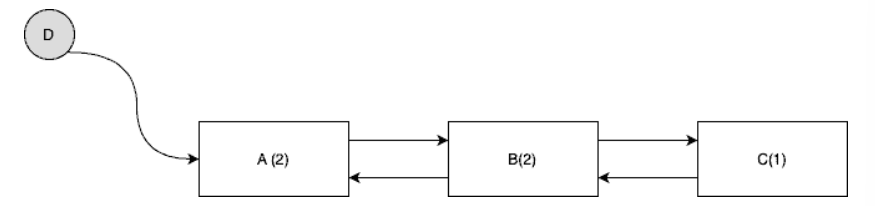

** To get rid of this, `garbage collector` or `cyclic garbage collector` comes. 

Q. Why does CPython use both `refernce couting` and `garbage collector`?
- Reference couting allow CPyton to free objects immediately when the reference count = 0. But it can't for `cyclic looped objects`, so garbage collector detects it free. 

* Key Takeaways:
 - Every python object has a `reference count`. 
 - Assigning another variable increase the referenc count.  
 - Deleting reduces. 
 - When `ref count = 0` python frees object 
 - `ref count` can't detect `cyclic reference` 
 - python use `garbage collector` for this. 

## Garbage Collection

* Can this object be reached from a live part of the running program?
- If No, then they should be removed

#### When does `garbage collection` run?
- this cyclic garbage collection runs periodically. (python occassionaly pauses and look for unreachable cycles, and frees them )
```
import gc
gc.collect()
```
- But we don't need to do this manully. 

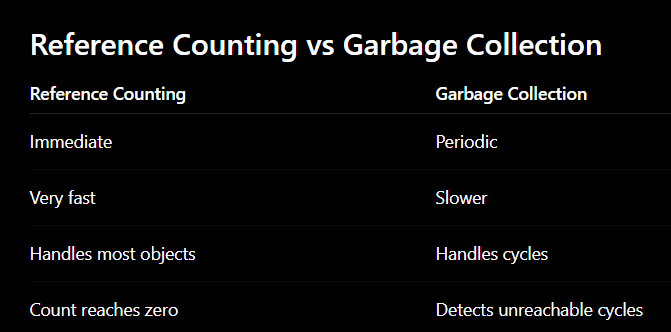

In [85]:
import gc
print(gc.isenabled())
## This means, automatic garbage collection is enabled. 

True


In [83]:
import gc 
print(gc.get_count())
## This shows the internal allocation counters used by the collector. 

(81, 0, 0)


In [ ]:
import gc
collected = gc.collect()
print(collected)
## this forces garbage collection, and returns the No. of unreachable objects. 


0


You write code  
        │  
        ▼  
Python creates objects  
        │  
        ▼  
Variables become names  
          │  
          ▼  
Names store references  
        │  
        ▼  
Objects live in RAM  
        │  
        ▼  
Objects are mutable or immutable  
        │  
        ▼  
Reference Count tracks how many references exist  
        │  
        ▼  
Reference Count = 0  
        │  
        ▼  
Object deleted unless   Reference Cycle    
        │  
        ▼  
Garbage Collector removes it

#  Numbers & Booleans

In [89]:
x = 10
print(type(x))

<class 'int'>


- So  `x` is an object of `int` class
- and it can have methods. 


In [92]:
print(dir(x)[:10])
# first few methods of the int class. 

['__abs__', '__add__', '__and__', '__bool__', '__ceil__', '__class__', '__delattr__', '__dir__', '__divmod__', '__doc__']


In [97]:
import numpy as np
np.int64(3) == 3

np.True_

`int` v/s `int32`
* numpy int and native int in python are not same 
* `int` offers flexible byte size, thus `inf` memory (whatever is RAM limit).
* but `int32`, `int16` or `int64` offers fixed bytes hence can store `2^(n-1)` value range only. 

#### Let's test for `int32`

In [107]:
### Testing for int32. 
max = 2**(32-1)-1
print(max)
## Now, lets add 1 to it (int31)
try:
    max = np.int32(max+1)
    print(max)
except Exception as e:
    print(e)


2147483647
Python int too large to convert to C long


In [111]:
## For native integer. 
max = 2**100
print(max)
max = 2**400
print(max)

1267650600228229401496703205376
2582249878086908589655919172003011874329705792829223512830659356540647622016841194629645353280137831435903171972747493376


### But why
- Because python doesnot store it in one fixed-size integer 
- Cpython stores integer into `a sequence of smaller chunks`.
- Stores in multiple boxes. 

### why `Python Integers` don't  `overflow`?
- got it!

### Floating point numbers

In [121]:
print(0.2+0.3)
print(0.1+0.2)

0.5
0.30000000000000004


 but why that extra 0000 and `then a 4`

1. So, computer doesnot understand decimal numbers/ Fractions.   
2. A CPU only understands binary.
3. And everything inside a computer is eventually represented using only `0s` and `1s`.  

So the fractions are also stored similar to the other regular numbers. 
```
123.45 = 1×10²
+2×10¹
+3×10⁰
+4×10⁻¹
+5×10⁻²
```
In the base of `10`

In the base of `2`
```
101.101

= 1×2²
+0×2¹
+1×2⁰
+1×2⁻¹
+0×2⁻²
+1×2⁻³```

* So `0.5` is basically `1/2` or `2^(-1)`, so `0.1` in binary. 
* but `0.1` in binary is not exact with finite no of decimal digits. 
* and hence computer apporximates it
* so `0.1` = `0.10000000000000555` kind of

A float has limited precision.

It cannot represent every decimal number exactly.

### Why?

In [11]:
print(0.1+0.2 == 0.3)

## because the stored apporximation produce a tiny rounding error when added. 

False


In [10]:
print(format(0.1, ".20f"))

print(format(0.4, ".20f"))

0.10000000000000000555
0.40000000000000002220


Floating-point arithmetic introduces tiny rounding errors.

Q. Why can't Python store 0.1 exactly?  
A. Because 0.1 has an infinite binary expansion.

In [13]:
## Python float follows IEEE-754 double precision
## 64 bits = 1 sign + 11 exponent + 52 fraction
## 52 bits ~ 2**(52-1) -1 ~ roughly 16 digtits precision. 
## Never compare float directly with ==. 